# Logistic Regression - Theory & Implementation with scikit-learn

## 1. Introduction

Logistic Regression is a **supervised learning** algorithm used for **binary classification** problems.

Unlike Linear Regression, which predicts a continuous value, Logistic Regression **predicts a probability that an input belongs to class 1**.

It models: 

$P(y = 1 \mid X)$

The output is constrained between 0 and 1 using the sigmoid function.

### 1.1. Scalar form

For a single observation with features $x_1, x_2, \dots, x_n $ the linear model is:

$z = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n$

Logistic Regression applies the sigmoid function:

$\hat{y} = \sigma(z)$

Where the sigmoid function is:

$\sigma(z) = \frac{1}{1 + e^{-z}}$

Therefore:

$\hat{y} = \frac{1}{1 + e^{-(\theta_0 + \theta_1 x_1 + \dots + \theta_n x_n)}} = P(y = 1 \mid X)$

#### Decision Rule

$\hat{y}_{class} =
\begin{cases}
1 & \text{if } \hat{y} \ge 0.5, \
0 & \text{otherwise}
\end{cases}
$

### 1.2. Vector / Matrix form

Let:

* $X \in \mathbb{R}^{m \times n}$
* $\theta \in \mathbb{R}^{n}$

The linear combination is:

$z = X\theta$

Predicted probabilities:

$\hat{y} = \sigma(X\theta)$

Sigmoid is applied element-wise.

## 2. Goal of Logistic Regression

### 2.1 Probabilistic Model

We assume:

$y_i \sim \text{Bernoulli}(p_i)$

Where:

$p_i = \sigma(\theta^T x_i)$

The probability of observing $y_i$ is:

$P(y_i \mid x_i) = p_i^{y_i} (1 - p_i)^{1 - y_i}$

### 2.2 Likelihood Function

For the full dataset:

$L(\theta) = \prod_{i=1}^{m}p_i^{y_i} (1 - p_i)^{1 - y_i}$

We want to **maximize the likelihood**.

Instead, we minimize the **negative log-likelihood**.

### 2.3 Cost Function (Binary Cross-Entropy)

Taking the negative log:

$J(\theta) = - \frac{1}{m}\sum_{i=1}^{m} \left[ y_i \log(p_i) - (1 - y_i) \log(1 - p_i) \right]$

This is called:

* Binary Cross-Entropy
* Log Loss

#### Why Not Mean Squared Error?

Using MSE:

$J(\theta) = \frac{1}{m} \sum (y - \hat{y})^2$

With a sigmoid function leads to a **non-convex cost function**.

Cross-entropy gives a **convex optimization problem**, ensuring a unique global minimum.

### 2.4 Gradient of the Cost Function

The gradient is:

$\nabla J(\theta) = \frac{1}{m}X^T (\hat{y} - y)$

This elegant form makes gradient descent efficient.

### 2.5 Optimization

Common optimization methods:

* Batch Gradient Descent
* Stochastic Gradient Descent (SGD)
* Newton’s Method
* LBFGS (used in scikit-learn)

## 3. Log-Odds Interpretation

Logistic Regression models the **log-odds**:

$\log \left(
\frac{p}{1-p}
\right)
\theta^T x
$

This is called the **logit function**.

**Interpretation**: Each coefficient $\theta_j$ represents the change in **log-odds** when feature $x_j$ increases by one unit.

## 4. Assumptions

1. Binary dependent variable
2. Independent observations
3. Linear relationship between features and log-odds
4. No strong multicollinearity
5. Large sample size preferred

## 5. Regularization

To prevent overfitting, we add a penalty term.

### 5.1. L2 Regularization

$J(\theta) = \text{LogLoss} + \lambda |\theta|^2$

### 5.2. L1 Regularization

$J(\theta) = \text{LogLoss} + \lambda |\theta|_1$

* L1 → sparsity
* L2 → smooth shrinkage

## 6. Implementation with Scikit-Learn

In [20]:
# Librairies imports
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [21]:
# Dataset generation with 2 features
X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [22]:
# Train the model
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [23]:
# Prediction and evaluation
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nModel Parameters")
print("Weights:", model.coef_)
print("Bias:", model.intercept_)

Accuracy: 0.88

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.88      0.88        51
           1       0.88      0.88      0.88        49

    accuracy                           0.88       100
   macro avg       0.88      0.88      0.88       100
weighted avg       0.88      0.88      0.88       100


Model Parameters
Weights: [[0.48558685 2.29571114]]
Bias: [-0.84237433]


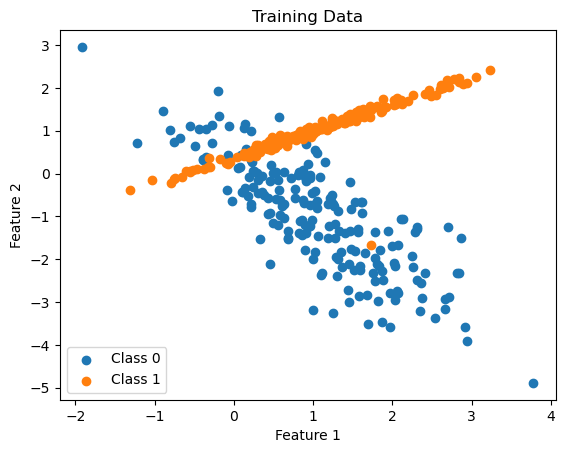

In [24]:
# Plotting training data with different colors for each class
plt.figure()

plt.scatter(X_train[y_train == 0][:, 0],
            X_train[y_train == 0][:, 1],
            label="Class 0")

plt.scatter(X_train[y_train == 1][:, 0],
            X_train[y_train == 1][:, 1],
            label="Class 1")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Training Data")
plt.legend()

plt.show()


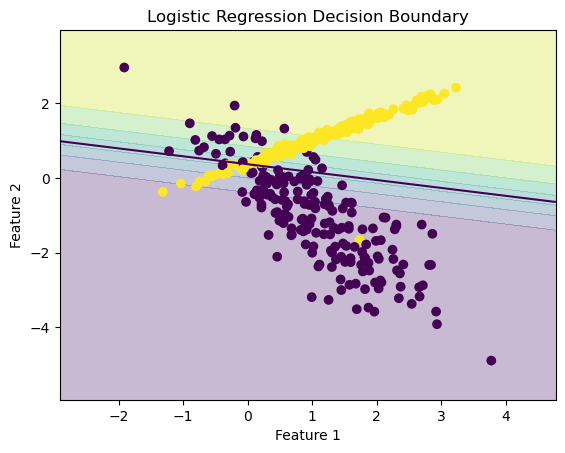

In [25]:
# Decision boundary visualization
# Create mesh grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Flatten grid
grid = np.c_[xx.ravel(), yy.ravel()]

# Predict probabilities
probs = model.predict_proba(grid)[:, 1]
probs = probs.reshape(xx.shape)

# Plot probability surface
plt.figure()

plt.contourf(xx, yy, probs, alpha=0.3)
plt.contour(xx, yy, probs, levels=[0.5])

# Plot training points
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Logistic Regression Decision Boundary")

plt.show()